Points: 30000
Segments: 120  (cuts: 179)
Median jump: 4.972, max jump: 2049.477, split factor: 10.0
Total length (open polylines): 189053.17
Time: 19.34 s
Grid cells: 86, k_near: 24, passes: 1, angle_alpha: 0.45


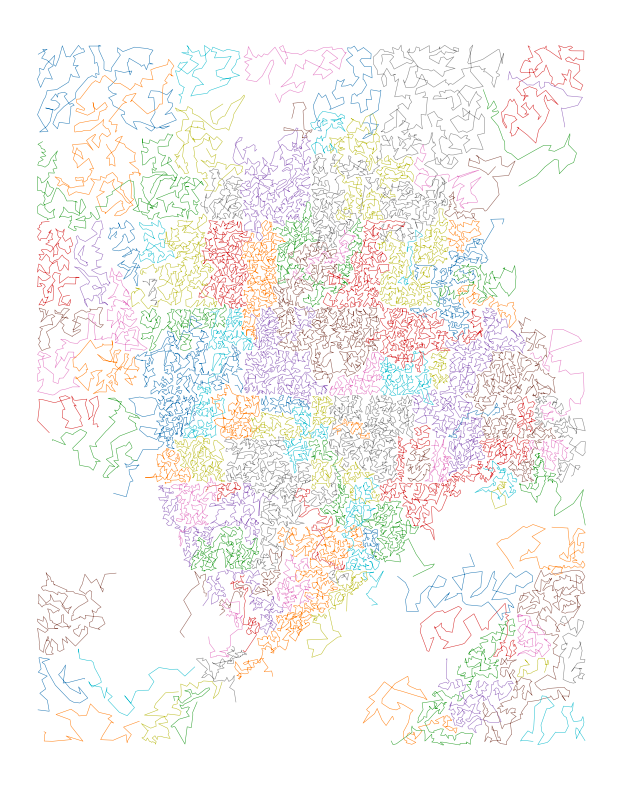

Saved SVG to: 10_einstein_tsp_smooth_split.svg
Saved PNG preview to: 10_einstein_tsp_smooth_split_preview.png


In [14]:
# Requirements: Pillow, numpy, matplotlib
# If needed:  !pip install pillow

import os
import math
import time
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# -----------------------
# Inputs
# -----------------------
image_path = "Albert_Einstein_sticks_his_tongue.jpg"
out_svg = "10_einstein_tsp_smooth_split.svg"
out_png = "10_einstein_tsp_smooth_split_preview.png"

# Sampling
n_points = 30000
gamma = 1.8
rng_seed = 123
jitter_within_pixel = True
invert_image = True

# Solver
angle_alpha = 0.45
grid_cells = None   # auto from n_points if None
k_near = 24
max_passes = 1
break_on_no_gain = True
tour_window = 0     # 0 disables tour distance window

# Splitting long jumps
split_factor = 10.0  # cut when segment length > split_factor * median_segment_length
min_points_per_segment = 20  # drop tiny fragments

# SVG
stroke_width = 0.7
stroke_color = "#000000"
margin = 10

# -----------------------
# Image sampling
# -----------------------
def load_grayscale(path, invert=False):
    img = Image.open(path).convert("L")
    if invert:
        img = ImageOps.invert(img)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr, img.size  # (w, h)

def sample_points_from_density(gray, n, gamma=1.5, jitter=True, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    h, w = gray.shape
    darkness = 1.0 - gray
    weights = np.clip(darkness, 0, 1) ** gamma
    s = float(weights.sum())
    if s <= 0:
        raise ValueError("Image has zero darkness.")
    probs = (weights / s).ravel()
    idx = rng.choice(w * h, size=n, replace=True, p=probs)
    ys = idx // w
    xs = idx % w
    if jitter:
        xs = xs + rng.random(n)
        ys = ys + rng.random(n)
    pts = np.column_stack([xs.astype(np.float32), ys.astype(np.float32)])
    return pts

# -----------------------
# Space-filling curve ordering (Morton/Z-order)
# -----------------------
def morton_code(xi, yi, bits=16):
    def part1by1(v):
        v &= 0x0000FFFF
        v = (v ^ (v << 8)) & 0x00FF00FF
        v = (v ^ (v << 4)) & 0x0F0F0F0F
        v = (v ^ (v << 2)) & 0x33333333
        v = (v ^ (v << 1)) & 0x55555555
        return v
    return (part1by1(xi) << 1) | part1by1(yi)

def morton_sort(points):
    pmin = points.min(axis=0)
    pmax = points.max(axis=0)
    span = np.maximum(pmax - pmin, 1e-9)
    q = (points - pmin) / span
    scale = 65535.0
    xi = np.clip((q[:,0] * scale).astype(np.uint32), 0, 65535)
    yi = np.clip((q[:,1] * scale).astype(np.uint32), 0, 65535)
    codes = morton_code(xi, yi)
    order = np.argsort(codes)
    return order

# -----------------------
# Spatial hash grid for neighbor queries
# -----------------------
class SpatialGrid:
    def __init__(self, pts, cells=128):
        self.pts = pts
        self.n = len(pts)
        self.cells = int(cells)
        pmin = pts.min(axis=0)
        pmax = pts.max(axis=0)
        span = np.maximum(pmax - pmin, 1e-9)
        self.q = (pts - pmin) / span
        self.pmin = pmin
        self.span = span
        self.ix = np.clip((self.q[:,0] * self.cells).astype(np.int32), 0, self.cells - 1)
        self.iy = np.clip((self.q[:,1] * self.cells).astype(np.int32), 0, self.cells - 1)
        self.bins = {}
        for i in range(self.n):
            key = (int(self.ix[i]), int(self.iy[i]))
            if key in self.bins:
                self.bins[key].append(i)
            else:
                self.bins[key] = [i]

    def _neighbors_in_radius(self, cx, cy, r):
        out = []
        for dx in range(-r, r+1):
            x = cx + dx
            if x < 0 or x >= self.cells:
                continue
            for dy in range(-r, r+1):
                y = cy + dy
                if y < 0 or y >= self.cells:
                    continue
                L = self.bins.get((x, y))
                if L:
                    out.extend(L)
        return out

    def k_nearest_candidates(self, idx, k=16, max_cell_radius=3, mask=None):
        cx, cy = int(self.ix[idx]), int(self.iy[idx])
        cand = []
        for r in range(0, max_cell_radius+1):
            cand = self._neighbors_in_radius(cx, cy, r)
            if len(cand) >= k + 1:
                break
        cand = np.array(cand, dtype=np.int32)
        cand = cand[cand != idx]
        if mask is not None:
            cand = cand[mask[cand]]
        if cand.size == 0:
            return cand
        d2 = np.sum((self.pts[cand] - self.pts[idx])**2, axis=1)
        if cand.size > k:
            keep = np.argpartition(d2, k)[:k]
            cand = cand[keep]
        return cand

# -----------------------
# Angle utilities
# -----------------------
def turn_cost(p_prev, p_curr, p_next):
    v1 = p_curr - p_prev
    v2 = p_next - p_curr
    n1 = np.linalg.norm(v1) + 1e-12
    n2 = np.linalg.norm(v2) + 1e-12
    c = np.dot(v1, v2) / (n1 * n2)
    c = np.clip(c, -1.0, 1.0)
    return 1.0 - c

def seg_len(a, b, pts):
    d = pts[a] - pts[b]
    return float(np.hypot(d[0], d[1]))

# -----------------------
# Local objective: length + alpha * turn
# -----------------------
def local_objective_delta_two_opt(order, i, j, pts, alpha):
    n = len(order)
    a, b = order[i], order[(i+1) % n]
    c, d = order[j], order[(j+1) % n]
    curr = seg_len(a, b, pts) + seg_len(c, d, pts)
    prop = seg_len(a, c, pts) + seg_len(b, d, pts)

    def angle_at(k, ord_):
        km1 = ord_[(k - 1) % n]
        k0  = ord_[k]
        kp1 = ord_[(k + 1) % n]
        return turn_cost(pts[km1], pts[k0], pts[kp1])

    idxs = {i, i+1, j, j+1}
    idxs = {x % n for x in idxs}
    curr_ang = 0.0
    for x in idxs:
        curr_ang += angle_at(x, order)

    tmp = order.copy()
    tmp[i+1:j+1] = order[i+1:j+1][::-1]
    prop_ang = 0.0
    for x in idxs:
        prop_ang += angle_at(x, tmp)

    delta = (prop - curr) + alpha * (prop_ang - curr_ang)
    return delta

def apply_two_opt(order, i, j, pos):
    seg = order[i+1:j+1]
    seg_rev = seg[::-1]
    order[i+1:j+1] = seg_rev
    for k in range(i+1, j+1):
        pos[order[k]] = k

# -----------------------
# Fast pipeline
# -----------------------
def build_initial_order(points):
    return morton_sort(points)

def improve_with_local_search(points, order, grid, alpha=0.3, k_near=16, max_passes=5, break_on_no_gain=True, tour_window=0):
    n = len(order)
    pos = np.empty(n, dtype=np.int32)
    for i, idx in enumerate(order):
        pos[idx] = i

    total_improved = False
    for _ in range(max_passes):
        improved = False
        for i in range(n - 2):
            a = order[i]
            b = order[i+1]
            cand_a = grid.k_nearest_candidates(a, k=k_near)
            cand_b = grid.k_nearest_candidates(b, k=k_near)
            if cand_a.size == 0 and cand_b.size == 0:
                continue
            cands = cand_a if cand_b.size == 0 else (cand_b if cand_a.size == 0 else np.unique(np.concatenate([cand_a, cand_b])))

            for pt_idx in cands:
                j = int(pos[pt_idx])
                if j <= i + 1 or j >= n - 1:
                    continue
                if j == i or j == i+1:
                    continue
                if tour_window and abs(j - i) > tour_window and abs(j - i - n) > tour_window:
                    continue
                gain = local_objective_delta_two_opt(order, i, j, points, alpha)
                if gain < -1e-9:
                    apply_two_opt(order, i, j, pos)
                    improved = True
        total_improved |= improved
        if break_on_no_gain and not improved:
            break
    return order, total_improved

# -----------------------
# Split long jumps into multiple polylines
# -----------------------
def split_tour_by_jump(points, order, factor=10.0, min_seg_pts=10):
    """Return list of index arrays. Split at edges whose length > factor * median_edge_length.
       Treat the tour as open by removing the wrap edge if that edge is a jump."""
    n = len(order)
    # lengths for edges (i -> i+1), including wrap
    p = points[order]
    dif = np.roll(p, -1, axis=0) - p
    seglens = np.sqrt((dif[:,0]**2) + (dif[:,1]**2))
    med = np.median(seglens)
    if med <= 0:
        return [order.copy()]
    cut_edges = np.where(seglens > factor * med)[0]

    # Build segments. A cut at edge i means break between i and i+1.
    starts = [0]
    for i in cut_edges:
        starts.append((i + 1) % n)
    starts = np.unique(starts)
    # Sort starts in tour order beginning at 0
    starts.sort()
    segments = []
    for s_idx in range(len(starts)):
        s = starts[s_idx]
        e = starts[(s_idx + 1) % len(starts)]
        if e > s:
            seg = order[s:e]
        else:
            # wrap segment, we will not wrap to the start, just end at n
            seg = order[s:n]
        if len(seg) >= min_seg_pts:
            segments.append(seg.copy())
    # Edge case. If no cuts, return the whole tour as one open polyline
    if not segments:
        if n >= min_seg_pts:
            segments = [order.copy()]
        else:
            segments = []
    return segments, med, seglens.max(), len(cut_edges)

# -----------------------
# SVG
# -----------------------
def save_svg_polylines(points, segments, path, stroke_width=1, stroke_color="#000000", margin=10):
    if not segments:
        return
    # bounding box over all points in segments
    all_idx = np.concatenate(segments)
    x = points[all_idx, 0]
    y = points[all_idx, 1]
    minx, maxx = float(x.min()), float(x.max())
    miny, maxy = float(y.min()), float(y.max())
    width = (maxx - minx) + 2 * margin
    height = (maxy - miny) + 2 * margin

    def polyline_str(idx):
        X = points[idx, 0] - minx + margin
        Y = points[idx, 1] - miny + margin
        return " ".join(f"{X[i]:.2f},{Y[i]:.2f}" for i in range(len(X)))

    lines = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width:.2f}" height="{height:.2f}" viewBox="0 0 {width:.2f} {height:.2f}">']
    for seg in segments:
        lines.append(f'  <polyline fill="none" stroke="{stroke_color}" stroke-width="{stroke_width}" points="{polyline_str(seg)}" />')
    lines.append('</svg>')
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

# -----------------------
# Run
# -----------------------
rng = np.random.default_rng(rng_seed)

gray, (W, H) = load_grayscale(image_path, invert=invert_image)
pts = sample_points_from_density(gray, n_points, gamma=gamma, jitter=jitter_within_pixel, rng=rng)

# Auto grid resolution that scales with n
if grid_cells is None:
    grid_cells = max(64, int(np.sqrt(n_points) // 2))
    grid_cells = min(grid_cells, 512)

t0 = time.time()
order = build_initial_order(pts)
grid = SpatialGrid(pts, cells=grid_cells)
order, _ = improve_with_local_search(
    pts, order, grid,
    alpha=angle_alpha,
    k_near=k_near,
    max_passes=max_passes,
    break_on_no_gain=break_on_no_gain,
    tour_window=tour_window
)

# Split long jumps
segments, median_jump, max_jump, n_cuts = split_tour_by_jump(pts, order, factor=split_factor, min_seg_pts=min_points_per_segment)

t1 = time.time()

def path_length_open_polyline(points, idx):
    p = points[idx]
    dif = p[1:] - p[:-1]
    seg = np.sqrt((dif[:,0]**2) + (dif[:,1]**2))
    return float(seg.sum())

total_length = sum(path_length_open_polyline(pts, seg) for seg in segments)

print(f"Points: {len(pts)}")
print(f"Segments: {len(segments)}  (cuts: {n_cuts})")
print(f"Median jump: {median_jump:.3f}, max jump: {max_jump:.3f}, split factor: {split_factor}")
print(f"Total length (open polylines): {total_length:.2f}")
print(f"Time: {t1 - t0:.2f} s")
print(f"Grid cells: {grid_cells}, k_near: {k_near}, passes: {max_passes}, angle_alpha: {angle_alpha}")

# Save SVG with multiple polylines
save_svg_polylines(pts, segments, out_svg, stroke_width=stroke_width, stroke_color=stroke_color, margin=margin)

# Plot for quick view (invert Y to match image orientation)
plt.figure(figsize=(8, 8))
for seg in segments:
    xy = pts[seg]
    plt.plot(xy[:, 0], H - xy[:, 1], linewidth=0.35)
plt.gca().set_aspect("equal", adjustable="box")
plt.axis("off")
plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.show()

print(f"Saved SVG to: {out_svg}")
print(f"Saved PNG preview to: {out_png}")

# Tips
# If you see too many small fragments, lower split_factor or raise min_points_per_segment.
# For very large n, keep k_near 16..24, grid_cells=None, and max_passes around 2..3.
